# Calculate the metrics from the csv

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

In [2]:
# --- CALCULATION ---
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_open/open_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_open_image/open_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_open/open_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_open_image/open_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_open/open_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_open_image/open_dist_matrix.csv"
}

# Dictionary to store all computed metrics
all_open_results = {}

for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_open_results[name] = bootstrap_from_csv(path, m=100, mode="open")


# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename for saving results
FILENAME = f"open_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_open_results, f)

print("✅ Results saved successfully.")


Processing DINOv2 (Video)
-> Calculating full set metrics (open)...
-> Bootstrapping 'open' metrics (100 iterations)...


100%|██████████| 100/100 [00:06<00:00, 15.37it/s]



Processing DINOv2 (Image)
-> Calculating full set metrics (open)...
-> Bootstrapping 'open' metrics (100 iterations)...


100%|██████████| 100/100 [00:07<00:00, 14.02it/s]



Processing SwinV2 (Video)
-> Calculating full set metrics (open)...
-> Bootstrapping 'open' metrics (100 iterations)...


...


Processing ViT (Video)
-> Calculating full set metrics (open)...
-> Bootstrapping 'open' metrics (100 iterations)...


100%|██████████| 100/100 [00:06<00:00, 14.97it/s]



Processing ViT (Image)
-> Calculating full set metrics (open)...
-> Bootstrapping 'open' metrics (100 iterations)...


100%|██████████| 100/100 [00:06<00:00, 15.23it/s]


-> Saving all results to results_data\open_world_benchmarks.pkl...
✅ Results saved successfully.


In [3]:
# Load the saved data
LOAD_PATH = "results_data/open_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")

Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']


In [4]:
# --- Print Open-World Results ---
print("\n" + "="*115)
print(f"{'Model (Rank)':<25} | {'FAR=1% [95% CI]':<28} | {'FAR=5% [95% CI]':<28} | {'FAR=10% [95% CI]':<28}")
print("="*115)

for name, res in all_results.items():
    # We use the full set FARs to find the correct threshold indices
    full_fars = res["full_set"]["fars"]
    
    row_vals_r1 = []
    row_vals_r5 = []
    
    for target in [0.01, 0.05, 0.10]:
        # Find the index in the threshold array that gets closest to the target FAR
        idx = np.argmin(np.abs(full_fars - target))
        
        # --- Rank-1: Full Set point estimate + Bootstrap CI ---
        r1_full = res["full_set"]["dirs_r1"][idx]
        r1_low  = res["dirs_r1_ci"][0][idx]
        r1_high = res["dirs_r1_ci"][1][idx]
        row_vals_r1.append(f"{r1_full:.3f} [{r1_low:.3f}, {r1_high:.3f}]")
        
        # --- Rank-5: Full Set point estimate + Bootstrap CI ---
        r5_full = res["full_set"]["dirs_r5"][idx]
        r5_low  = res["dirs_r1_ci"][0][idx] # Note: ensure your aggregator saved dirs_r5_ci!
        r5_high = res["dirs_r1_ci"][1][idx]
        
        # Handling the case where you might have separate R5 CI arrays
        if "dirs_r5_ci" in res:
            r5_low  = res["dirs_r5_ci"][0][idx]
            r5_high = res["dirs_r5_ci"][1][idx]
            
        row_vals_r5.append(f"{r5_full:.3f} [{r5_low:.3f}, {r5_high:.3f}]")
    
    # Print Rank 1 row
    print(f"{name + ' (R1)':<25} | {row_vals_r1[0]:<28} | {row_vals_r1[1]:<28} | {row_vals_r1[2]:<28}")
    
    # Print Rank 5 row
    print(f"{name + ' (R5)':<25} | {row_vals_r5[0]:<28} | {row_vals_r5[1]:<28} | {row_vals_r5[2]:<28}")
    
    print("-" * 115)


Model (Rank)              | FAR=1% [95% CI]              | FAR=5% [95% CI]              | FAR=10% [95% CI]            
DINOv2 (Video) (R1)       | 0.062 [0.048, 0.084]         | 0.126 [0.106, 0.152]         | 0.226 [0.200, 0.254]        
DINOv2 (Video) (R5)       | 0.067 [0.052, 0.088]         | 0.143 [0.120, 0.168]         | 0.261 [0.234, 0.287]        
-------------------------------------------------------------------------------------------------------------------
DINOv2 (Image) (R1)       | 0.039 [0.027, 0.053]         | 0.111 [0.092, 0.130]         | 0.181 [0.157, 0.206]        
DINOv2 (Image) (R5)       | 0.042 [0.030, 0.056]         | 0.127 [0.110, 0.151]         | 0.216 [0.190, 0.243]        
-------------------------------------------------------------------------------------------------------------------
SwinV2 (Video) (R1)       | 0.023 [0.014, 0.035]         | 0.048 [0.035, 0.066]         | 0.082 [0.064, 0.099]        
SwinV2 (Video) (R5)       | 0.031 [0.021, 0.042]     

C:\Users\marko\AppData\Local\Temp\ipykernel_21288\2684373465.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


KeyError: 'lower_dirs_r1'

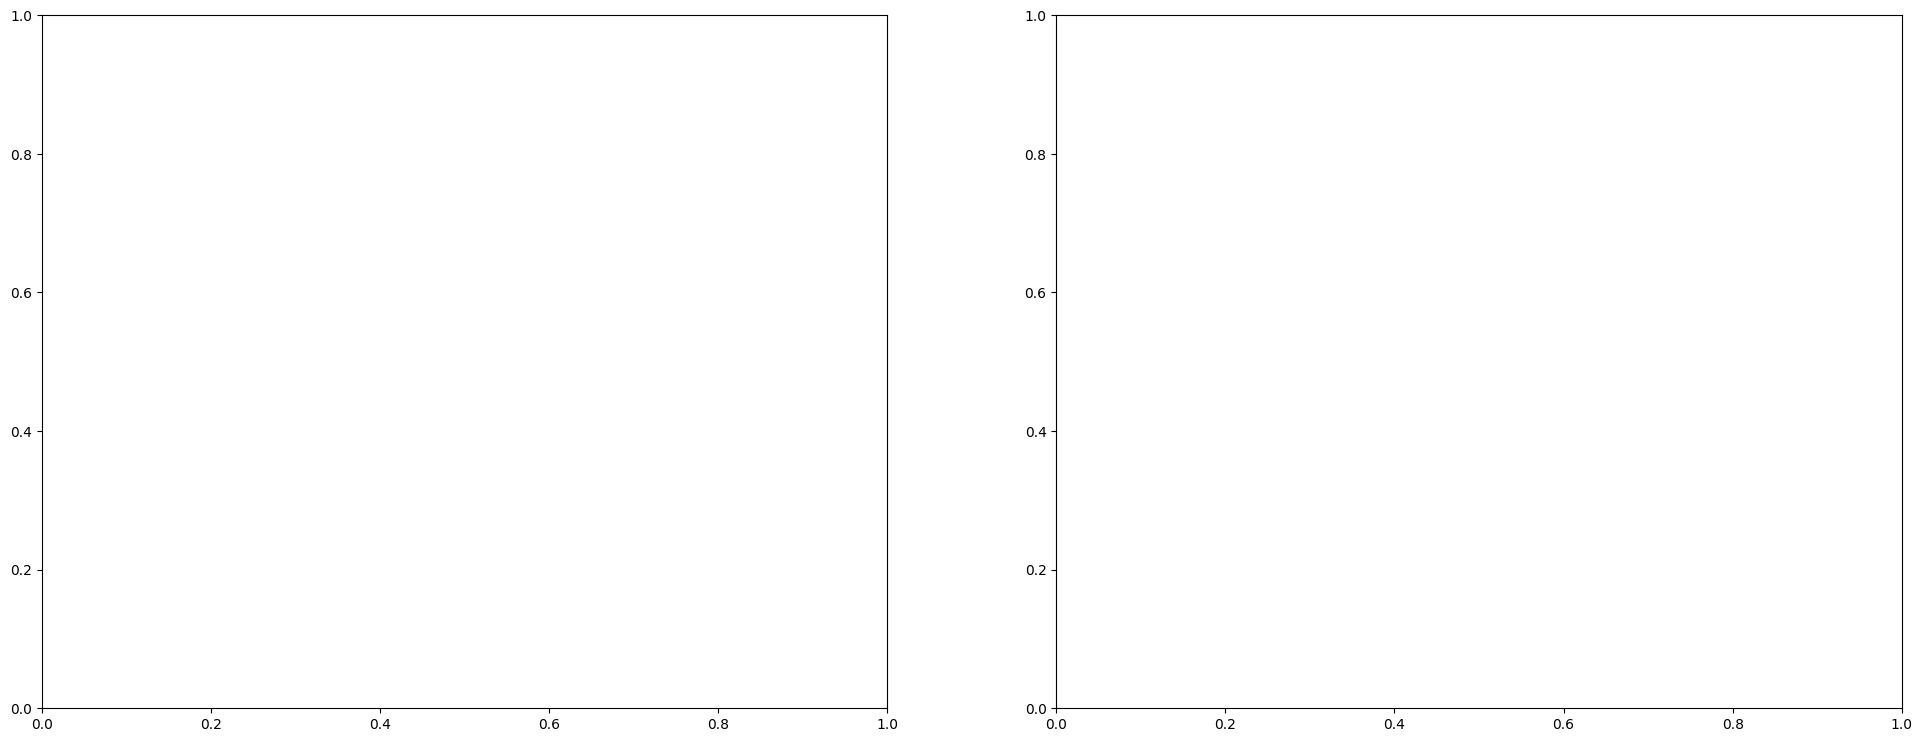

In [5]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# -------------------------------------------------------------
MAX_FAR = 0.15 
FAR_TICK_STEP = 0.02
FONT_SIZE = 26 

# Adjusted these to 0.7 or similar if your DINOv2 results go higher than 0.4
MAX_DIR_R1 = 0.7 
MAX_DIR_R5 = 0.8  

# -------------------------------------------------------------
# --- Plotting Open-World Curves (Side-by-Side Subplots) ---
# -------------------------------------------------------------

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(24, 9)) 

plot_configs = [
    {"suffix": "r1", "title": "Rank-1", "max_dir": MAX_DIR_R1, "ax": axes[0]},
    {"suffix": "r5", "title": "Rank-5", "max_dir": MAX_DIR_R5, "ax": axes[1]}
]

for config in plot_configs:
    ax = config["ax"]
    colors = plt.cm.get_cmap('tab10', len(all_results))
    
    for i, (name, res) in enumerate(all_results.items()):
        # Pull FARs and DIRs from the Full Set (Point Estimate)
        fars_full = res["full_set"]["fars"]
        dirs_full = res["full_set"][f"dirs_{config['suffix']}"]
        
        # Pull Confidence Intervals from the Bootstrap results
        # Assuming you updated aggregator to return lower_dirs_r1, upper_dirs_r1, etc.
        dirs_lower = res[f"lower_dirs_{config['suffix']}"]
        dirs_upper = res[f"upper_dirs_{config['suffix']}"]
        
        color = colors(i)
        
        # Plot the Shaded Uncertainty Interval (95% CI)
        ax.fill_between(fars_full, dirs_lower, dirs_upper, color=color, alpha=0.15)
        
        # Plot the Full Set Line
        line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
        ax.plot(fars_full, dirs_full, color=color, linestyle=line_style, linewidth=3, label=name)

    # --- Format the Subplot with Larger Fonts ---
    ax.set_title(config["title"], fontsize=FONT_SIZE + 4, fontweight='bold')
    ax.set_xlabel("False Alarm Rate (FAR)", fontsize=FONT_SIZE + 2, fontweight='bold')
    ax.set_ylabel("Detection & Identification Rate (DIR)", fontsize=FONT_SIZE + 2, fontweight='bold')

    # --- Axis Tick Labels ---
    ax.set_xticks(np.arange(0, MAX_FAR + 0.01, step=FAR_TICK_STEP))
    ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE)

    # --- Dynamic Axis Control ---
    ax.set_xlim(0, MAX_FAR) 
    ax.set_ylim(0, config["max_dir"]) 

    ax.grid(True, linestyle='--', alpha=0.6)

    # --- Legend Configuration ---
    # Legend is only needed on one plot to save space, but keeping it on both per your code
    ax.legend(fontsize=FONT_SIZE - 4, loc='lower right', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig("figs/open_world.png")
plt.show()